# 02 · 방법 2 — Das–Markowitz: 계좌마다 (H, α) 두 숫자

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/02_%EB%B0%A9%EB%B2%952_DasMarkowitz.ipynb)

**W06 M8 GBI 강의본 34~41장 · 61장 · 부록 B-6(134~137장)** 을 재현합니다.
원 논문: Das · Markowitz · Scheid · Statman (2010), JFQA 45(2) — 가상 자산 셋, 계정 셋(은퇴 · 교육 · 상속).

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 문제와 자산 셋 | 34장 | 미달 확률 P(R < H) ≤ α 안에서 기대수익 최대 |
| 손계산 ① 한 포트폴리오 검사 | 35장 | 60/30/10 → 8.50% · 9.06% · −6.40% · 2.05% |
| 손계산 ② 두 자산 | 36장 | w* 52.2% · 2차식 · 근 고르기 |
| 행렬 일반화 | 37장 | Σ⁻¹1, A · B · C · D, g · v, γ 3.795 |
| 세 계정 | 38장 | γ 3.795 · 2.706 · 0.877 |
| 롱온리 | 39 · 40장 | 채권 0에 묶고 다시 → 0 · 8.9 · 91.1, SLSQP = 엑셀 해 찾기 |
| 합쳐도 효율 | 41장 | 전체 γ 2.174, 합산 롱온리 손실 12.4bp |
| 가능성 점검 | 61장 · B-6 ④ | Q_max = −2.31% |

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 문제와 자산 셋 (강의 34장)
계좌 하나의 문제 — **미달 확률 한도 안에서 기대수익률을 최대로**

max_w  w·μ   s.t.  P(R_p < H) ≤ α,  비중 합 = 1

정규분포면 P(R_p < H) ≤ α ⇔ **m − z·σ ≥ H** (z = −Φ⁻¹(α), α 5%면 1.645). 확률 조건이 평균 · 표준편차 조건이 됩니다.

In [2]:
from scipy.stats import norm
NAMES = ["채권형", "저위험 주식형", "고위험 주식형"]
MU = np.array([0.05, 0.10, 0.25])
SD = np.array([0.05, 0.20, 0.50])
CORR = np.array([[1, 0, 0], [0, 1, 0.2], [0, 0.2, 1]])
S = CORR * np.outer(SD, SD)                    # 공분산 행렬 Σ
print("Σ =\n", S)
ACCTS = [("은퇴", -0.10, 0.05), ("교육", -0.05, 0.15), ("상속", -0.15, 0.20)]   # (계정, H, α)
for a, H, al in ACCTS:
    print(f"{a}: H {H:+.0%} · α {al:.0%} → z = −Φ⁻¹(α) = {-norm.ppf(al):.4f}")

Σ =
 [[0.0025 0.     0.    ]
 [0.     0.04   0.02  ]
 [0.     0.02   0.25  ]]
은퇴: H -10% · α 5% → z = −Φ⁻¹(α) = 1.6449
교육: H -5% · α 15% → z = −Φ⁻¹(α) = 1.0364
상속: H -15% · α 20% → z = −Φ⁻¹(α) = 0.8416


## 2. 손계산 ① — 포트폴리오 하나가 조건을 지키는지 검사 (강의 35장)
은퇴 계정(H = −10%, α = 5%)에 채권 60 · 저위험 30 · 고위험 10%를 넣어 봅니다.
분산의 네 항: 0.6²×0.05² + 0.3²×0.20² + 0.1²×0.50² + 2×0.3×0.1×0.02.

In [3]:
w = np.array([0.6, 0.3, 0.1])
m = w @ MU
terms = [w[0]**2 * S[0, 0], w[1]**2 * S[1, 1], w[2]**2 * S[2, 2], 2 * w[1] * w[2] * S[1, 2]]
var = sum(terms); sd = math.sqrt(var)
low5 = m - 1.645 * sd
miss = norm.cdf((-0.10 - m) / sd)
print("분산의 네 항:", " + ".join(f"{t:.4f}" for t in terms), f"= {var:.4f}")
print(f"m = {m:.2%} · σ = {sd:.2%} · 하위 5% = {low5:.2%} {'≥' if low5 >= -0.10 else '<'} H = −10% · 미달 확률 = {miss:.2%}")
check("60/30/10 기대수익 (%)", 100 * m, 8.50, 0.005, ".2f")
check("60/30/10 분산", var, 0.0082, 1e-6, ".4f")
check("60/30/10 σ (%)", 100 * sd, 9.06, 0.005, ".2f")
check("60/30/10 하위 5% (%)", 100 * low5, -6.40, 0.005, ".2f")
check("60/30/10 미달 확률 (%)", 100 * miss, 2.05, 0.005, ".2f")

분산의 네 항: 0.0009 + 0.0036 + 0.0025 + 0.0012 = 0.0082
m = 8.50% · σ = 9.06% · 하위 5% = -6.40% ≥ H = −10% · 미달 확률 = 2.05%
✓ 60/30/10 기대수익 (%): 계산 8.50 · 강의 8.50 (허용 ±0.005)
✓ 60/30/10 분산: 계산 0.0082 · 강의 0.0082 (허용 ±1e-06)
✓ 60/30/10 σ (%): 계산 9.06 · 강의 9.06 (허용 ±0.005)
✓ 60/30/10 하위 5% (%): 계산 -6.40 · 강의 -6.40 (허용 ±0.005)
✓ 60/30/10 미달 확률 (%): 계산 2.05 · 강의 2.05 (허용 ±0.005)


## 3. 손계산 ② — 두 자산이면 비중 하나를 조건에 딱 맞춘다 (강의 36장)
교육용 축소: 채권형(5% · 5%) + 저위험 주식형(10% · 20%), 상관 0, 은퇴 계정(H −10%, α 5%).
m(w) = 5% + 5%·w, σ(w) = √((1−w)²×0.05² + w²×0.20²). 기대수익을 최대로 하려면 **제약이 등호로 걸리는 데까지** w를 올립니다.

In [4]:
z5 = 1.645
m2 = lambda w: 0.05 + 0.05 * w
s2 = lambda w: math.sqrt((1 - w)**2 * 0.05**2 + w**2 * 0.20**2)
for wt in (0.5, 0.6):
    lb = m2(wt) - z5 * s2(wt)
    print(f"시험 w = {wt}: {m2(wt):.1%} − 1.645 × {s2(wt):.2%} = {lb:.2%} → {'통과 (여유 %.2f%%p)' % (100 * (lb + 0.10)) if lb >= -0.10 else '위반'}")
check("w=0.5 하위 5% (%)", 100 * (m2(0.5) - z5 * s2(0.5)), -9.46, 0.005, ".2f")
check("w=0.6 하위 5% (%)", 100 * (m2(0.6) - z5 * s2(0.6)), -12.01, 0.005, ".2f")
# 등호로 놓고 제곱: (15% + 5% w)² = 1.645² [(1−w)²×0.05² + w²×0.20²]  →  a w² + b w + c = 0
a = 0.05**2 - z5**2 * (0.05**2 + 0.20**2)
b = 2 * 0.15 * 0.05 + z5**2 * 2 * 0.05**2
c = 0.15**2 - z5**2 * 0.05**2
roots = np.roots([a, b, c])
print(f"2차식: {a:.4f} w² + {b:.4f} w + {c:.4f} = 0 → 근 {np.round(roots, 4)}")
w_star = roots[roots > 0][0]          # 음수 근은 제곱하며 생긴 가짜 해 — 버린다
print(f"w* = {w_star:.1%} · m = {m2(w_star):.2%} · σ = {s2(w_star):.2%} · 하위 5% = {m2(w_star) - z5 * s2(w_star):.2%}")
check("2차식 a", a, -0.1125, 0.0001, ".4f")
check("2차식 b", b, 0.0285, 0.0001, ".4f")
check("2차식 c", c, 0.0157, 0.0001, ".4f")
check("두 자산 w* (%)", 100 * w_star, 52.2, 0.05, ".1f")
check("두 자산 m (%)", 100 * m2(w_star), 7.61, 0.005, ".2f")
check("두 자산 σ (%)", 100 * s2(w_star), 10.70, 0.005, ".2f")

시험 w = 0.5: 7.5% − 1.645 × 10.31% = -9.46% → 통과 (여유 0.54%p)
시험 w = 0.6: 8.0% − 1.645 × 12.17% = -12.01% → 위반
✓ w=0.5 하위 5% (%): 계산 -9.46 · 강의 -9.46 (허용 ±0.005)
✓ w=0.6 하위 5% (%): 계산 -12.01 · 강의 -12.01 (허용 ±0.005)
2차식: -0.1125 w² + 0.0285 w + 0.0157 = 0 → 근 [ 0.5217 -0.2681]
w* = 52.2% · m = 7.61% · σ = 10.70% · 하위 5% = -10.00%
✓ 2차식 a: 계산 -0.1125 · 강의 -0.1125 (허용 ±0.0001)
✓ 2차식 b: 계산 0.0285 · 강의 0.0285 (허용 ±0.0001)
✓ 2차식 c: 계산 0.0157 · 강의 0.0157 (허용 ±0.0001)
✓ 두 자산 w* (%): 계산 52.2 · 강의 52.2 (허용 ±0.05)
✓ 두 자산 m (%): 계산 7.61 · 강의 7.61 (허용 ±0.005)
✓ 두 자산 σ (%): 계산 10.70 · 강의 10.70 (허용 ±0.005)


**그래프 — 확률 제약선.** 주식 비중 w를 바꾸며 기대수익 m(w)과 하위 5% 경계 m − 1.645σ를 그립니다. 하위 경계가 H = −10% 선과 만나는 곳이 w\*입니다(그 오른쪽은 위반).

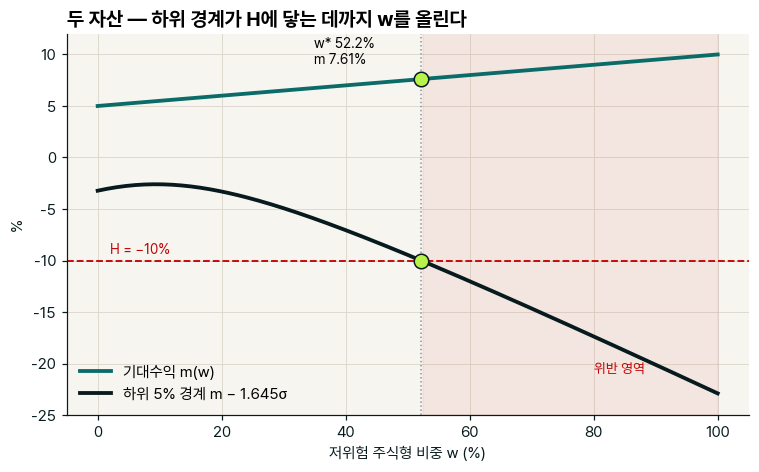

In [5]:
ws = np.linspace(0, 1, 201)
ms = np.array([m2(x) for x in ws]); lbs = np.array([m2(x) - z5 * s2(x) for x in ws])
fig, ax = plt.subplots()
ax.plot(ws * 100, ms * 100, color=TEAL, lw=2.5, label="기대수익 m(w)")
ax.plot(ws * 100, lbs * 100, color=INK, lw=2.5, label="하위 5% 경계 m − 1.645σ")
ax.axhline(-10, color=RED, ls="--", lw=1.2); ax.text(2, -9.3, "H = −10%", color=RED, fontsize=9)
ax.fill_between(ws * 100, -25, 15, where=lbs < -0.10, color=RED, alpha=0.06)
ax.axvline(w_star * 100, color=GRAY, lw=1, ls=":")
ax.scatter([w_star * 100] * 2, [m2(w_star) * 100, -10], s=90, color=LIME, edgecolor=INK, zorder=5)
ax.annotate(f"w* {w_star:.1%}\nm {m2(w_star):.2%}", (w_star * 100, m2(w_star) * 100), xytext=(-70, 10),
            textcoords="offset points", fontsize=9)
ax.text(80, -21, "위반 영역", color=RED, fontsize=9)
ax.set_ylim(-25, 12); ax.set_xlabel("저위험 주식형 비중 w (%)"); ax.set_ylabel("%")
ax.set_title("두 자산 — 하위 경계가 H에 닿는 데까지 w를 올린다"); ax.legend(loc="lower left")
plt.show()

## 4. 일반화 — 자산이 n개면 행렬로 (강의 37장 · 부록 B-6 ③)
비중 합 = 1에서 점수(평균 − γ/2 × 분산)를 최대로 하면 해는 **w(γ) = g + v/γ** — 최소분산 포트폴리오 g와 위험을 더 지는 방향 v.

A = 1ᵀΣ⁻¹μ, B = μᵀΣ⁻¹μ, C = 1ᵀΣ⁻¹1, D = BC − A²(원문 각주 6), 강의의 d = B − A²/C = D/C.
m(γ) = A/C + d/γ, σ²(γ) = 1/C + d/γ². x = 1/γ로 두고 제약을 등호로 걸면 x의 방정식 하나가 됩니다.

In [6]:
Si = np.linalg.inv(S); one = np.ones(3)
Si1 = Si @ one
A_ = one @ Si @ MU; B_ = MU @ Si @ MU; C_ = one @ Si @ one; D_ = B_ * C_ - A_**2; d_ = B_ - A_**2 / C_
g = Si1 / C_
v = Si @ (MU - A_ / C_ * one)
print("Σ⁻¹1 =", np.round(Si1, 2), f"→ C = {C_:.2f}")
print(f"A = {A_:.3f} · B = {B_:.4f} · C = {C_:.2f} · D = {D_:.2f} · d = D/C = {d_:.5f}")
print(f"a/c = {A_/C_:.4f} · 1/c = {1/C_:.6f}")
print("g (최소분산) =", np.round(g, 3), " v (위험 방향) =", np.round(v, 3), f"(v의 합 {v.sum():.1e})")
check("Σ⁻¹1 채권", Si1[0], 400, 0.01, ".2f"); check("Σ⁻¹1 저위험", Si1[1], 23.96, 0.005, ".2f"); check("Σ⁻¹1 고위험", Si1[2], 2.08, 0.005, ".2f")
check("A", A_, 22.917, 0.0005, ".3f"); check("B", B_, 1.4167, 0.00005, ".4f"); check("C", C_, 426.04, 0.005, ".2f")
check("D", D_, 78.39, 0.005, ".2f"); check("d", d_, 0.18399, 0.000005, ".5f")
check("a/c", A_ / C_, 0.0538, 0.00005, ".4f"); check("1/c", 1 / C_, 0.002347, 0.0000005, ".6f")
for i, (gl, vl) in enumerate(zip([0.939, 0.056, 0.005], [-1.516, 0.795, 0.721])):
    check(f"g[{NAMES[i]}]", g[i], gl, 0.0005, ".3f"); check(f"v[{NAMES[i]}]", v[i], vl, 0.0005, ".3f")

Σ⁻¹1 = [400.    23.96   2.08] → C = 426.04
A = 22.917 · B = 1.4167 · C = 426.04 · D = 78.39 · d = D/C = 0.18399
a/c = 0.0538 · 1/c = 0.002347
g (최소분산) = [0.939 0.056 0.005]  v (위험 방향) = [-1.516  0.795  0.721] (v의 합 -8.9e-16)
✓ Σ⁻¹1 채권: 계산 400.00 · 강의 400.00 (허용 ±0.01)
✓ Σ⁻¹1 저위험: 계산 23.96 · 강의 23.96 (허용 ±0.005)
✓ Σ⁻¹1 고위험: 계산 2.08 · 강의 2.08 (허용 ±0.005)
✓ A: 계산 22.917 · 강의 22.917 (허용 ±0.0005)
✓ B: 계산 1.4167 · 강의 1.4167 (허용 ±5e-05)
✓ C: 계산 426.04 · 강의 426.04 (허용 ±0.005)
✓ D: 계산 78.39 · 강의 78.39 (허용 ±0.005)
✓ d: 계산 0.18399 · 강의 0.18399 (허용 ±5e-06)
✓ a/c: 계산 0.0538 · 강의 0.0538 (허용 ±5e-05)
✓ 1/c: 계산 0.002347 · 강의 0.002347 (허용 ±5e-07)
✓ g[채권형]: 계산 0.939 · 강의 0.939 (허용 ±0.0005)
✓ v[채권형]: 계산 -1.516 · 강의 -1.516 (허용 ±0.0005)
✓ g[저위험 주식형]: 계산 0.056 · 강의 0.056 (허용 ±0.0005)
✓ v[저위험 주식형]: 계산 0.795 · 강의 0.795 (허용 ±0.0005)
✓ g[고위험 주식형]: 계산 0.005 · 강의 0.005 (허용 ±0.0005)
✓ v[고위험 주식형]: 계산 0.721 · 강의 0.721 (허용 ±0.0005)


**은퇴 계정을 손으로** — a/c + d·x − 1.645·√(1/c + d·x²) = −0.10을 양변 제곱하면 x의 2차식(강의 37장):

In [7]:
H, z = -0.10, -norm.ppf(0.05)                     # z = 1.6449 (반올림 1.645를 쓰면 γ가 3.796으로 셋째 자리가 흔들린다)
k = A_ / C_ - H                                    # a/c − H
qa, qb, qc = d_**2 - z**2 * d_, 2 * d_ * k, k**2 - z**2 / C_
xr = np.roots([qa, qb, qc])
print(f"2차식: {qa:.4f} x² + {qb:.4f} x + {qc:.4f} = 0 → 근 {np.round(xr, 4)}")
x_pos = xr[xr > 0][0]
lhs = lambda x: A_ / C_ + d_ * x - z * math.sqrt(1 / C_ + d_ * x * x)
print(f"양수 근 x = {x_pos:.4f} → 원래 식 {lhs(x_pos):+.4f} (= H) · 음수 근은 x = 1/γ > 0이 아니라 버린다")
gamma_ret = 1 / x_pos
w_ret = g + v * x_pos
print(f"γ = 1/x = {gamma_ret:.3f} → 비중 = g + x·v = {np.round(100 * w_ret, 1)}%")
check("2차식 계수 x²", qa, -0.4639, 0.0001, ".4f"); check("2차식 계수 x", qb, 0.0566, 0.0001, ".4f"); check("2차식 상수", qc, 0.0173, 0.0001, ".4f")
check("양수 근 x", x_pos, 0.2635, 0.0001, ".4f"); check("음수 근", xr[xr < 0][0], -0.142, 0.0005, ".3f")
check("은퇴 γ", gamma_ret, 3.795, 0.0005, ".3f")

2차식: -0.4639 x² + 0.0566 x + 0.0173 = 0 → 근 [ 0.2635 -0.1415]
양수 근 x = 0.2635 → 원래 식 -0.1000 (= H) · 음수 근은 x = 1/γ > 0이 아니라 버린다
γ = 1/x = 3.795 → 비중 = g + x·v = [53.9 26.6 19.5]%
✓ 2차식 계수 x²: 계산 -0.4639 · 강의 -0.4639 (허용 ±0.0001)
✓ 2차식 계수 x: 계산 0.0566 · 강의 0.0566 (허용 ±0.0001)
✓ 2차식 상수: 계산 0.0173 · 강의 0.0173 (허용 ±0.0001)
✓ 양수 근 x: 계산 0.2635 · 강의 0.2635 (허용 ±0.0001)
✓ 음수 근: 계산 -0.142 · 강의 -0.142 (허용 ±0.0005)
✓ 은퇴 γ: 계산 3.795 · 강의 3.795 (허용 ±0.0005)


## 5. 세 계정에 같은 순서를 (강의 38장)
계정마다 (H, α)만 다릅니다. 근의 공식 대신 `brentq`(구간 안의 근 찾기)로 x = 1/γ를 풀어도 같습니다.

In [8]:
from scipy.optimize import brentq
def solve_gamma(H, alpha):
    """(H, α) → γ: 효율선 위에서 확률 제약이 등호로 걸리는 점"""
    z = -norm.ppf(alpha)
    f = lambda x: A_ / C_ + d_ * x - z * math.sqrt(1 / C_ + d_ * x * x) - H
    return 1 / brentq(f, 1e-9, 10)

LECT = {"은퇴": (3.795, [53.9, 26.6, 19.5], 10.23, 12.30), "교육": (2.706, [37.9, 35.0, 27.1], 12.18, 16.57),
        "상속": (0.877, [-78.9, 96.2, 82.7], 26.35, 49.13)}
SOL = {}
for a, H, al in ACCTS:
    gm = solve_gamma(H, al); w = g + v / gm
    SOL[a] = (gm, w)
    mm, ss = w @ MU, math.sqrt(w @ S @ w)
    print(f"{a} (H {H:+.0%}, α {al:.0%}): γ {gm:.3f} · 비중 {np.round(100 * w, 1)}% → 기대 {mm:.2%} · σ {ss:.2%}")
    L = LECT[a]
    check(f"{a} γ", gm, L[0], 0.0005, ".3f")
    for i in range(3):
        check(f"{a} {NAMES[i]} (%)", 100 * w[i], L[1][i], 0.05, ".1f")
    check(f"{a} 기대수익 (%)", 100 * mm, L[2], 0.005, ".2f"); check(f"{a} σ (%)", 100 * ss, L[3], 0.005, ".2f")

은퇴 (H -10%, α 5%): γ 3.795 · 비중 [53.9 26.6 19.5]% → 기대 10.23% · σ 12.30%
✓ 은퇴 γ: 계산 3.795 · 강의 3.795 (허용 ±0.0005)
✓ 은퇴 채권형 (%): 계산 53.9 · 강의 53.9 (허용 ±0.05)
✓ 은퇴 저위험 주식형 (%): 계산 26.6 · 강의 26.6 (허용 ±0.05)
✓ 은퇴 고위험 주식형 (%): 계산 19.5 · 강의 19.5 (허용 ±0.05)
✓ 은퇴 기대수익 (%): 계산 10.23 · 강의 10.23 (허용 ±0.005)
✓ 은퇴 σ (%): 계산 12.30 · 강의 12.30 (허용 ±0.005)
교육 (H -5%, α 15%): γ 2.706 · 비중 [37.9 35.  27.1]% → 기대 12.18% · σ 16.57%
✓ 교육 γ: 계산 2.706 · 강의 2.706 (허용 ±0.0005)
✓ 교육 채권형 (%): 계산 37.9 · 강의 37.9 (허용 ±0.05)
✓ 교육 저위험 주식형 (%): 계산 35.0 · 강의 35.0 (허용 ±0.05)
✓ 교육 고위험 주식형 (%): 계산 27.1 · 강의 27.1 (허용 ±0.05)
✓ 교육 기대수익 (%): 계산 12.18 · 강의 12.18 (허용 ±0.005)
✓ 교육 σ (%): 계산 16.57 · 강의 16.57 (허용 ±0.005)
상속 (H -15%, α 20%): γ 0.877 · 비중 [-78.9  96.2  82.7]% → 기대 26.35% · σ 49.13%
✓ 상속 γ: 계산 0.877 · 강의 0.877 (허용 ±0.0005)
✓ 상속 채권형 (%): 계산 -78.9 · 강의 -78.9 (허용 ±0.05)
✓ 상속 저위험 주식형 (%): 계산 96.2 · 강의 96.2 (허용 ±0.05)
✓ 상속 고위험 주식형 (%): 계산 82.7 · 강의 82.7 (허용 ±0.05)
✓ 상속 기대수익 (%): 계산 26.35 · 강의 26.35 (허용 ±0.005)
✓ 상속 σ (%): 

**그래프 — γ에 따른 비중.** w(γ) = g + v/γ. γ가 작을수록(미달 기준이 느슨할수록) 위험 방향 v를 더 섞어 주식이 늘고, 상속(γ 0.877)은 채권을 공매도(차입)합니다.

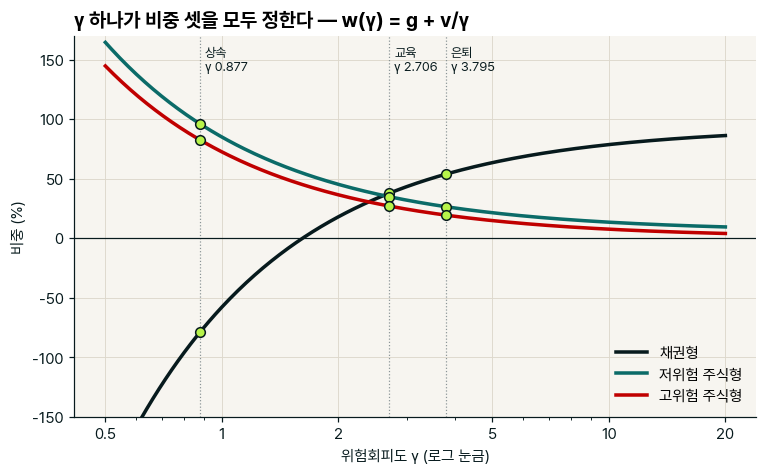

In [9]:
gs = np.geomspace(0.5, 20, 300)
Wg = g[None, :] + v[None, :] / gs[:, None]
fig, ax = plt.subplots()
for i, c in enumerate([INK, TEAL, RED]):
    ax.plot(gs, Wg[:, i] * 100, color=c, lw=2.3, label=NAMES[i])
for a, (gm, w) in SOL.items():
    ax.axvline(gm, color=GRAY, lw=0.8, ls=":")
    ax.text(gm * 1.03, 160, f"{a}\nγ {gm:.3f}", fontsize=8.5, color=INK, va="top")
    ax.scatter([gm] * 3, w * 100, s=40, color=LIME, edgecolor=INK, zorder=5)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xscale("log"); ax.set_xticks([0.5, 1, 2, 5, 10, 20], ["0.5", "1", "2", "5", "10", "20"])
ax.set_ylim(-150, 170); ax.set_xlabel("위험회피도 γ (로그 눈금)"); ax.set_ylabel("비중 (%)")
ax.set_title("γ 하나가 비중 셋을 모두 정한다 — w(γ) = g + v/γ"); ax.legend(loc="lower right")
plt.show()

## 6. 롱온리 — 음수 자산을 0에 묶고 다시 푼다 (강의 39장)
상속 계정 H = −15%, α = 20% → z = Φ⁻¹(0.80) = 0.8416. 무제약 해의 채권 −78.9%는 롱온리 위반입니다.
① 채권 = 0으로 묶고(KKT의 활성 제약) ② 남는 두 자산(저위험 1 − w, 고위험 w)으로 손계산 ②와 같은 방법:
m(w) = 10% + 15%·w, σ²(w) = 0.04 − 0.04w + 0.25w².

In [10]:
zi = norm.ppf(0.80)
mL = lambda w: 0.10 + 0.15 * w
sL = lambda w: math.sqrt(0.04 - 0.04 * w + 0.25 * w * w)
print(f"z = Φ⁻¹(0.80) = {zi:.4f}")
for wt in (0.8, 1.0):
    lb = mL(wt) - zi * sL(wt)
    print(f"시험 w = {wt}: m {mL(wt):.1%} · σ {sL(wt):.2%} · 하위 20% {lb:.2%} → {'통과' if lb >= -0.15 else '위반'}")
check("w=0.8 하위 20% (%)", 100 * (mL(0.8) - zi * sL(0.8)), -12.50, 0.005, ".2f")
check("w=1.0 하위 20% (%)", 100 * (mL(1.0) - zi * sL(1.0)), -17.08, 0.005, ".2f")
# (0.25 + 0.15w)² = z² (0.04 − 0.04w + 0.25w²)
la, lb_, lc = 0.15**2 - zi**2 * 0.25, 2 * 0.25 * 0.15 + zi**2 * 0.04, 0.25**2 - zi**2 * 0.04
lr = np.roots([la, lb_, lc])
print(f"2차식: {la:.4f} w² + {lb_:.4f} w + {lc:.4f} = 0 → 근 {np.round(lr, 3)}")
wl = lr[lr > 0][0]
w_lo = np.array([0.0, 1 - wl, wl])
print(f"롱온리 해: {np.round(100 * w_lo, 1)}% · 기대 {w_lo @ MU:.2%} · σ {math.sqrt(w_lo @ S @ w_lo):.2%} (모두 0 이상 → 끝)")
check("z(80%)", zi, 0.8416, 0.00005, ".4f")
check("롱온리 2차식 w²", la, -0.1546, 0.0001, ".4f"); check("롱온리 2차식 w", lb_, 0.1033, 0.0001, ".4f"); check("롱온리 2차식 상수", lc, 0.0342, 0.0001, ".4f")
check("롱온리 고위험 w* (%)", 100 * wl, 91.1, 0.05, ".1f"); check("다른 근", lr[lr < 0][0], -0.243, 0.0005, ".3f")
check("롱온리 저위험 (%)", 100 * w_lo[1], 8.9, 0.05, ".1f")
check("롱온리 기대 (%)", 100 * (w_lo @ MU), 23.67, 0.005, ".2f"); check("롱온리 σ (%)", 100 * math.sqrt(w_lo @ S @ w_lo), 45.94, 0.005, ".2f")

z = Φ⁻¹(0.80) = 0.8416
시험 w = 0.8: m 22.0% · σ 40.99% · 하위 20% -12.50% → 통과
시험 w = 1.0: m 25.0% · σ 50.00% · 하위 20% -17.08% → 위반
✓ w=0.8 하위 20% (%): 계산 -12.50 · 강의 -12.50 (허용 ±0.005)
✓ w=1.0 하위 20% (%): 계산 -17.08 · 강의 -17.08 (허용 ±0.005)
2차식: -0.1546 w² + 0.1033 w + 0.0342 = 0 → 근 [ 0.911 -0.243]
롱온리 해: [ 0.   8.9 91.1]% · 기대 23.67% · σ 45.94% (모두 0 이상 → 끝)
✓ z(80%): 계산 0.8416 · 강의 0.8416 (허용 ±5e-05)
✓ 롱온리 2차식 w²: 계산 -0.1546 · 강의 -0.1546 (허용 ±0.0001)
✓ 롱온리 2차식 w: 계산 0.1033 · 강의 0.1033 (허용 ±0.0001)
✓ 롱온리 2차식 상수: 계산 0.0342 · 강의 0.0342 (허용 ±0.0001)
✓ 롱온리 고위험 w* (%): 계산 91.1 · 강의 91.1 (허용 ±0.05)
✓ 다른 근: 계산 -0.243 · 강의 -0.243 (허용 ±0.0005)
✓ 롱온리 저위험 (%): 계산 8.9 · 강의 8.9 (허용 ±0.05)
✓ 롱온리 기대 (%): 계산 23.67 · 강의 23.67 (허용 ±0.005)
✓ 롱온리 σ (%): 계산 45.94 · 강의 45.94 (허용 ±0.005)


## 7. 같은 문제를 scipy SLSQP로 — 엑셀 '해 찾기'와 같은 일 (강의 40장)
엑셀: 목표 B7(기대수익) 최대 · 변수 B2:B4 · 제약 B6 = 1, B10 ≥ B11 · GRG 비선형 · **'제한되지 않는 변수를 음이 아닌 수로 설정'** 체크 = 롱온리.
파이썬: `bounds=[(0, 1)]*3`가 그 체크 하나와 같습니다. 체크를 끄면(bounds 없음) 공매도 허용 해가 나옵니다.

In [11]:
from scipy.optimize import minimize
cons = [{"type": "eq", "fun": lambda w: w.sum() - 1},
        {"type": "ineq", "fun": lambda w: w @ MU - zi * np.sqrt(w @ S @ w) + 0.15}]   # 하위 20% 경계 ≥ −15%
r_lo = minimize(lambda w: -w @ MU, [1/3] * 3, method="SLSQP", bounds=[(0, 1)] * 3, constraints=cons)
r_free = minimize(lambda w: -w @ MU, [1/3] * 3, method="SLSQP", constraints=cons)
for lab, rr in [("체크 켬(롱온리)", r_lo), ("체크 끔(공매도 허용)", r_free)]:
    x = rr.x
    print(f"{lab}: {np.round(100 * x, 3)}% · 기대 {x @ MU:.2%} · 하위 20% 경계 {x @ MU - zi * math.sqrt(x @ S @ x):.2%}")
check("SLSQP 롱온리 저위험 (%)", 100 * r_lo.x[1], 8.893, 0.005, ".3f")
check("SLSQP 롱온리 고위험 (%)", 100 * r_lo.x[2], 91.107, 0.005, ".3f")
check("SLSQP 롱온리 기대 (%)", 100 * (r_lo.x @ MU), 23.67, 0.005, ".2f")
check("SLSQP 공매도 허용 채권 (%)", 100 * r_free.x[0], -78.9, 0.05, ".1f")
check("SLSQP 공매도 허용 기대 (%)", 100 * (r_free.x @ MU), 26.35, 0.005, ".2f")

체크 켬(롱온리): [ 0.     8.893 91.107]% · 기대 23.67% · 하위 20% 경계 -15.00%
체크 끔(공매도 허용): [-78.906  96.202  82.704]% · 기대 26.35% · 하위 20% 경계 -15.00%
✓ SLSQP 롱온리 저위험 (%): 계산 8.893 · 강의 8.893 (허용 ±0.005)
✓ SLSQP 롱온리 고위험 (%): 계산 91.107 · 강의 91.107 (허용 ±0.005)
✓ SLSQP 롱온리 기대 (%): 계산 23.67 · 강의 23.67 (허용 ±0.005)
✓ SLSQP 공매도 허용 채권 (%): 계산 -78.9 · 강의 -78.9 (허용 ±0.05)
✓ SLSQP 공매도 허용 기대 (%): 계산 26.35 · 강의 26.35 (허용 ±0.005)


## 8. 공매도를 허용하면 합쳐도 효율선 위 (강의 41장 · 부록 B-6 ④)
계좌 배분 a = 은퇴 60 · 교육 20 · 상속 20%. 각 계좌가 g + v/γ_k 꼴이라 합쳐도 같은 꼴 → **1/γ_전체 = Σ a_k/γ_k**.

In [12]:
alloc = np.array([0.6, 0.2, 0.2])
gams = np.array([SOL[a][0] for a, *_ in ACCTS])
g_tot = 1 / (alloc / gams).sum()
w_tot = sum(al * SOL[a][1] for al, (a, *_) in zip(alloc, ACCTS))
print(f"전체 γ = 1 / (0.6/{gams[0]:.3f} + 0.2/{gams[1]:.3f} + 0.2/{gams[2]:.3f}) = {g_tot:.3f}  (산술 가중평균 {alloc @ gams:.2f} 아님)")
print(f"합친 비중 {np.round(100 * w_tot, 1)}% = g + v/γ_전체 {np.round(100 * (g + v / g_tot), 1)}% · 기대 {w_tot @ MU:.2%} · σ {math.sqrt(w_tot @ S @ w_tot):.2%}")
check("전체 γ", g_tot, 2.174, 0.0005, ".3f"); check("γ 산술평균", alloc @ gams, 2.99, 0.005, ".2f")
for i, L in enumerate([24.2, 42.2, 33.7]):
    check(f"합친 {NAMES[i]} (%)", 100 * w_tot[i], L, 0.05, ".1f")
check("합친 기대 (%)", 100 * (w_tot @ MU), 13.84, 0.005, ".2f"); check("합친 σ (%)", 100 * math.sqrt(w_tot @ S @ w_tot), 20.32, 0.005, ".2f")

전체 γ = 1 / (0.6/3.795 + 0.2/2.706 + 0.2/0.877) = 2.174  (산술 가중평균 2.99 아님)
합친 비중 [24.2 42.2 33.7]% = g + v/γ_전체 [24.2 42.2 33.7]% · 기대 13.84% · σ 20.32%
✓ 전체 γ: 계산 2.174 · 강의 2.174 (허용 ±0.0005)
✓ γ 산술평균: 계산 2.99 · 강의 2.99 (허용 ±0.005)
✓ 합친 채권형 (%): 계산 24.2 · 강의 24.2 (허용 ±0.05)
✓ 합친 저위험 주식형 (%): 계산 42.2 · 강의 42.2 (허용 ±0.05)
✓ 합친 고위험 주식형 (%): 계산 33.7 · 강의 33.7 (허용 ±0.05)
✓ 합친 기대 (%): 계산 13.84 · 강의 13.84 (허용 ±0.005)
✓ 합친 σ (%): 계산 20.32 · 강의 20.32 (허용 ±0.005)


## 9. 계정마다 롱온리면 — 합산 손실 12bp (강의 38장)
은퇴 · 교육은 원래 양수라 그대로, 상속만 0 · 8.9 · 91.1%. 합치면 σ 19.38% · 기대 13.30% → 같은 σ의 (롱온리) 효율선 13.43%보다 **연 12bp** 낮습니다.
원문 p.328의 합산 σ 19.89%는 19.38%의 오기로 보입니다(19.89%면 효율선 13.65%, 손실 약 34bp로 원문의 12bp와 모순).

In [13]:
w_agg_lo = 0.6 * SOL["은퇴"][1] + 0.2 * SOL["교육"][1] + 0.2 * r_lo.x
m_agg, s_agg = w_agg_lo @ MU, math.sqrt(w_agg_lo @ S @ w_agg_lo)
def eff_long_only(sig_target):
    """같은 σ에서 롱온리로 낼 수 있는 최대 기대수익"""
    cs = [{"type": "eq", "fun": lambda w: w.sum() - 1}, {"type": "ineq", "fun": lambda w: sig_target**2 - w @ S @ w}]
    rr = minimize(lambda w: -w @ MU, [1/3] * 3, method="SLSQP", bounds=[(0, 1)] * 3, constraints=cs, options={"ftol": 1e-12})
    return rr.x @ MU, rr.x
eff_unc = lambda s: A_ / C_ + math.sqrt(d_ * (s * s - 1 / C_))     # 무제약 효율선
e_lo, w_eff = eff_long_only(s_agg)
loss_bp = (e_lo - m_agg) * 1e4
print(f"합산 롱온리 비중 {np.round(100 * w_agg_lo, 1)}% · 기대 {m_agg:.2%} · σ {s_agg:.2%}")
print(f"같은 σ의 효율선: 롱온리 {e_lo:.2%} · 무제약 {eff_unc(s_agg):.2%} → 손실 {loss_bp:.1f}bp")
print(f"오기 점검: σ 19.89%면 효율선 {eff_unc(0.1989):.2%} → 손실 {(eff_unc(0.1989) - m_agg) * 1e4:.0f}bp")
# 강의 'CPPI + Das–Markowitz' 장의 39.9 · 24.7 · 35.4는 합이 100이 되게 맞춘 반올림 — 계산값 35.35%라 허용오차를 0.06%p로 둔다
for i, L in enumerate([39.9, 24.7, 35.4]):
    check(f"합산 롱온리 {NAMES[i]} (%)", 100 * w_agg_lo[i], L, 0.06, ".2f")
check("합산 롱온리 기대 (%)", 100 * m_agg, 13.30, 0.005, ".2f"); check("합산 롱온리 σ (%)", 100 * s_agg, 19.38, 0.005, ".2f")
check("같은 σ 효율선 (%)", 100 * e_lo, 13.43, 0.005, ".2f"); check("롱온리 손실 (bp)", loss_bp, 12.4, 0.05, ".1f")
check("오기 σ 19.89%의 효율선 (%)", 100 * eff_unc(0.1989), 13.65, 0.005, ".2f")
check("오기 σ 19.89%의 손실 (bp, 강의 '약 34')", (eff_unc(0.1989) - m_agg) * 1e4, 34, 1.0, ".1f")

합산 롱온리 비중 [39.9 24.7 35.3]% · 기대 13.30% · σ 19.38%
같은 σ의 효율선: 롱온리 13.43% · 무제약 13.43% → 손실 12.4bp
오기 점검: σ 19.89%면 효율선 13.65% → 손실 35bp
✓ 합산 롱온리 채권형 (%): 계산 39.94 · 강의 39.90 (허용 ±0.06)
✓ 합산 롱온리 저위험 주식형 (%): 계산 24.71 · 강의 24.70 (허용 ±0.06)
✓ 합산 롱온리 고위험 주식형 (%): 계산 35.35 · 강의 35.40 (허용 ±0.06)
✓ 합산 롱온리 기대 (%): 계산 13.30 · 강의 13.30 (허용 ±0.005)
✓ 합산 롱온리 σ (%): 계산 19.38 · 강의 19.38 (허용 ±0.005)
✓ 같은 σ 효율선 (%): 계산 13.43 · 강의 13.43 (허용 ±0.005)
✓ 롱온리 손실 (bp): 계산 12.4 · 강의 12.4 (허용 ±0.05)
✓ 오기 σ 19.89%의 효율선 (%): 계산 13.65 · 강의 13.65 (허용 ±0.005)
✓ 오기 σ 19.89%의 손실 (bp, 강의 '약 34'): 계산 34.9 · 강의 34.0 (허용 ±1)


## 10. 가능성 점검 — Q_max = −2.31% (강의 61장 · 부록 B-6 ④)
하위 α 경계 m − zσ를 가장 높게 만드는 포트폴리오의 값 Q_max = A/C − √((z² − d)/C). H ≤ Q_max일 때만 목표가 가능합니다.
"원금 손실 확률 5% 이하"(H = 0, α 5%)는 0 > −2.31%라 이 자산들로는 **불가능** — 목표 · 기간 · 저축을 다시 묻습니다.

In [14]:
Qmax = A_ / C_ - math.sqrt((z5**2 - d_) / C_)
# 수치 확인: 효율선 위 γ를 훑어 하위 5% 경계의 최댓값을 찾는다
gg = np.geomspace(0.5, 200, 20000)
lb_line = A_ / C_ + d_ / gg - z5 * np.sqrt(1 / C_ + d_ / gg**2)
print(f"Q_max(식) = {Qmax:.2%} · 수치 최댓값 = {lb_line.max():.2%} (γ ≈ {gg[lb_line.argmax()]:.1f})")
check("Q_max (%)", 100 * Qmax, -2.31, 0.005, ".2f")
check("Q_max 수치 = 식", 100 * lb_line.max(), 100 * Qmax, 0.001, ".3f")

Q_max(식) = -2.31% · 수치 최댓값 = -2.31% (γ ≈ 32.8)
✓ Q_max (%): 계산 -2.31 · 강의 -2.31 (허용 ±0.005)
✓ Q_max 수치 = 식: 계산 -2.315 · 강의 -2.315 (허용 ±0.001)


## 11. 그래프 — 효율선 위의 계좌 · 합산 · 롱온리 점, 그리고 확률 제약선
(σ, 기대수익) 평면에서 계정의 확률 제약 m − zσ ≥ H는 **기울기 z의 직선 m = H + zσ 위쪽**입니다.
기대수익을 최대로 하는 해는 효율선과 이 직선이 만나는 점(위쪽 교점)입니다. (38 · 41장)

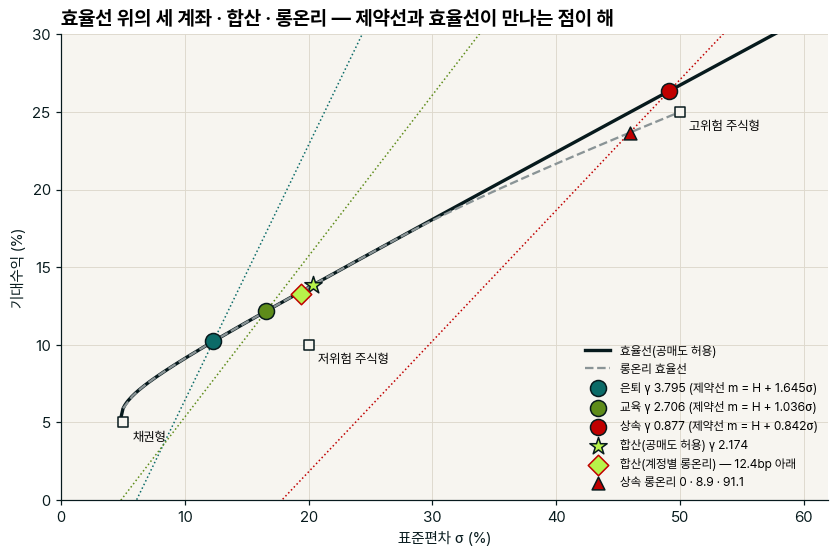

In [15]:
sg = np.linspace(math.sqrt(1 / C_) + 1e-6, 0.62, 400)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(sg * 100, [eff_unc(s) * 100 for s in sg], color=INK, lw=2.2, label="효율선(공매도 허용)")
lo_s = np.linspace(0.05, 0.50, 60)
ax.plot(lo_s * 100, [eff_long_only(s)[0] * 100 for s in lo_s], color=GRAY, lw=1.5, ls="--", label="롱온리 효율선")
for i in range(3):
    ax.scatter(SD[i] * 100, MU[i] * 100, marker="s", s=50, color=IVORY, edgecolor=INK, zorder=4)
    ax.annotate(NAMES[i], (SD[i] * 100, MU[i] * 100), xytext=(6, -12), textcoords="offset points", fontsize=8.5)
cols = {"은퇴": TEAL, "교육": OLIVE, "상속": RED}
for a, H, al in ACCTS:
    gm, w = SOL[a]; s_, m_ = math.sqrt(w @ S @ w), w @ MU
    zz = -norm.ppf(al)
    xs = np.linspace(0, 0.62, 10)
    ax.plot(xs * 100, (H + zz * xs) * 100, color=cols[a], lw=1, ls=":")
    ax.scatter(s_ * 100, m_ * 100, s=110, color=cols[a], edgecolor=INK, zorder=5, label=f"{a} γ {gm:.3f} (제약선 m = H + {zz:.3f}σ)")
s_t, m_t = math.sqrt(w_tot @ S @ w_tot), w_tot @ MU
ax.scatter(s_t * 100, m_t * 100, s=140, marker="*", color=LIME, edgecolor=INK, zorder=6, label=f"합산(공매도 허용) γ {g_tot:.3f}")
ax.scatter(s_agg * 100, m_agg * 100, s=90, marker="D", color=LIME, edgecolor=RED, zorder=6, label=f"합산(계정별 롱온리) — {loss_bp:.1f}bp 아래")
ax.scatter(math.sqrt(r_lo.x @ S @ r_lo.x) * 100, r_lo.x @ MU * 100, s=70, marker="^", color=RED, edgecolor=INK, zorder=6, label="상속 롱온리 0 · 8.9 · 91.1")
ax.set_xlim(0, 62); ax.set_ylim(0, 30)
ax.set_xlabel("표준편차 σ (%)"); ax.set_ylabel("기대수익 (%)")
ax.set_title("효율선 위의 세 계좌 · 합산 · 롱온리 — 제약선과 효율선이 만나는 점이 해")
ax.legend(fontsize=8, loc="lower right")
plt.show()

## 12. 정리
- (H, α)를 묻는 것은 γ를 묻는 것과 같은 말 — "5% 확률로도 −10% 아래는 안 된다" ⇔ γ = 3.795.
- 공매도를 허용하면 합쳐도 효율(전체 γ는 역수 평균), 계정마다 롱온리를 걸면 합산 손실은 연 12bp.
- 정규분포 · 한 기간 가정의 닫힌 해입니다. 두꺼운 꼬리에서 같은 문제를 **세어서** 푸는 것은 06 노트북(방법 3으로 방법 2 문제).

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [16]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 87 / 87 통과


---
## 바꿔 보기 (연습 문제)

1. 은퇴 계정의 α를 5% → 1%로 줄이면 γ와 비중은? (`solve_gamma(-0.10, 0.01)`) 채권 비중은 늘어나는가?
2. 두 주식형의 상관을 0.2 → 0.5로 올리면(`CORR`을 바꾸고 4절부터 다시 실행) 세 계정의 γ와 Q_max는 어떻게 바뀌나?
3. "원금 손실 확률 5% 이하"(H = 0, α 5%)를 가능하게 하려면 H를 얼마까지 낮춰야 하나? α를 몇 %까지 올려야 하나?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [17]:
# 여기에 직접 해 보기

In [18]:
# 여기에 직접 해 보기

In [19]:
# 여기에 직접 해 보기